##Imports

In [88]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer



##reading data and changing features to CamelCase

In [89]:

# Re-read the CSV to ensure a clean state for dataframe with original column names
dataframe = pd.read_csv('https://drive.google.com/uc?id=1O5mGIoNzTQKqu4kAA-8N7QEk23u_2Bq4')


dataframe = dataframe.rename(columns = {
    'work_year':'Work_Year',
    'experience_level':'Experience_Level',
    'employment_type':'Employment_Type',
    'job_title':'Job_Title',
    'salary':'Salary',
    'salary_currency':'Salary_Currency',
    'salary_in_usd':'Salary_In_USD',
    'employee_residence':'Employee_Residence',
    'remote_ratio':'Remote_Ratio',
    'company_location':'Company_Location',
    'company_size':'Company_Size'
})


##Data pre-processing

In [90]:
# Separate features (X) and target (Y) from the original dataframe
X = dataframe.drop(columns=['Salary', 'Salary_Currency', 'Salary_In_USD'])
Y = dataframe['Salary_In_USD']

# Apply specific custom encodings to X
# Experience_Level: EN=1, MI=2, SE=3, EX=4
experience_mapping = {'EN': 1, 'MI': 2, 'SE': 3, 'EX': 4}
X['Experience_Level'] = X['Experience_Level'].map(experience_mapping)

# Employment_Type: FT=1, CT=2, PT=3, FL=4
employment_mapping = {'FT': 1, 'CT': 2, 'PT': 3, 'FL': 4}
X['Employment_Type'] = X['Employment_Type'].map(employment_mapping)

# Company_Size: S=1, M=2, L=3
company_size_mapping = {'S': 1, 'M': 2, 'L': 3}
X['Company_Size'] = X['Company_Size'].map(company_size_mapping)

# Apply LabelEncoder to the remaining categorical columns in X
categorical_cols_le = ['Job_Title', 'Employee_Residence', 'Company_Location']

for col in categorical_cols_le:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# Split data into 70% training, 15% validation, and 15% test sets
# First split: 85% for training+validation, 15% for test
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, test_size=0.15, random_state=32)

# Second split: From the 85% (X_train_val, Y_train_val), split to get 70% training and 15% validation
# validate size = 0.15 / 0.85 = 0.176470588
X_train, X_validate, Y_train, Y_validate = train_test_split(X_train_val, Y_train_val, test_size=0.176470588, random_state=32)

print("Data preprocessing and splitting complete.")
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_validate shape: {X_validate.shape}, Y_validate shape: {Y_validate.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

Data preprocessing and splitting complete.
X_train shape: (2627, 8), Y_train shape: (2627,)
X_validate shape: (564, 8), Y_validate shape: (564,)
X_test shape: (564, 8), Y_test shape: (564,)


## Univariate Analysis of Numerical Columns



In [ ]:
numerical_cols = ['Salary_In_USD', 'Work_Year', 'Remote_Ratio']
print("Descriptive statistics for numerical columns:")
print(dataframe[numerical_cols].describe())

# Visualize distributions
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(dataframe['Salary_In_USD'], kde=True, bins=30)
plt.title('Distribution of Salary in USD')
plt.xlabel('Salary in USD')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(dataframe['Remote_Ratio'], kde=True, bins=3)
plt.title('Distribution of Remote Ratio')
plt.xlabel('Remote Ratio')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.countplot(data=dataframe, x='Work_Year', hue='Work_Year', palette='viridis', legend=False)
plt.title('Count of Work Year')
plt.xlabel('Work Year')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Univariate Analysis of Categorical Columns



In [86]:
categorical_cols = ['Experience_Level', 'Employment_Type', 'Job_Title', 'Company_Size', 'Company_Location', 'Employee_Residence']

print("Value counts for categorical columns:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(dataframe[col].value_counts())


Value counts for categorical columns:

--- Experience_Level ---
Experience_Level
SE    2516
MI     805
EN     320
EX     114
Name: count, dtype: int64

--- Employment_Type ---
Employment_Type
FT    3718
PT      17
CT      10
FL      10
Name: count, dtype: int64

--- Job_Title ---
Job_Title
Data Engineer                1040
Data Scientist                840
Data Analyst                  612
Machine Learning Engineer     289
Analytics Engineer            103
                             ... 
Principal Data Architect        1
Head of Machine Learning        1
Cloud Data Architect            1
Staff Data Scientist            1
Finance Data Analyst            1
Name: count, Length: 93, dtype: int64

--- Company_Size ---
Company_Size
M    3153
L     454
S     148
Name: count, dtype: int64

--- Company_Location ---
Company_Location
US    3040
GB     172
CA      87
ES      77
IN      58
      ... 
CN       1
NZ       1
CL       1
MD       1
MT       1
Name: count, Length: 72, dtype: int64

---

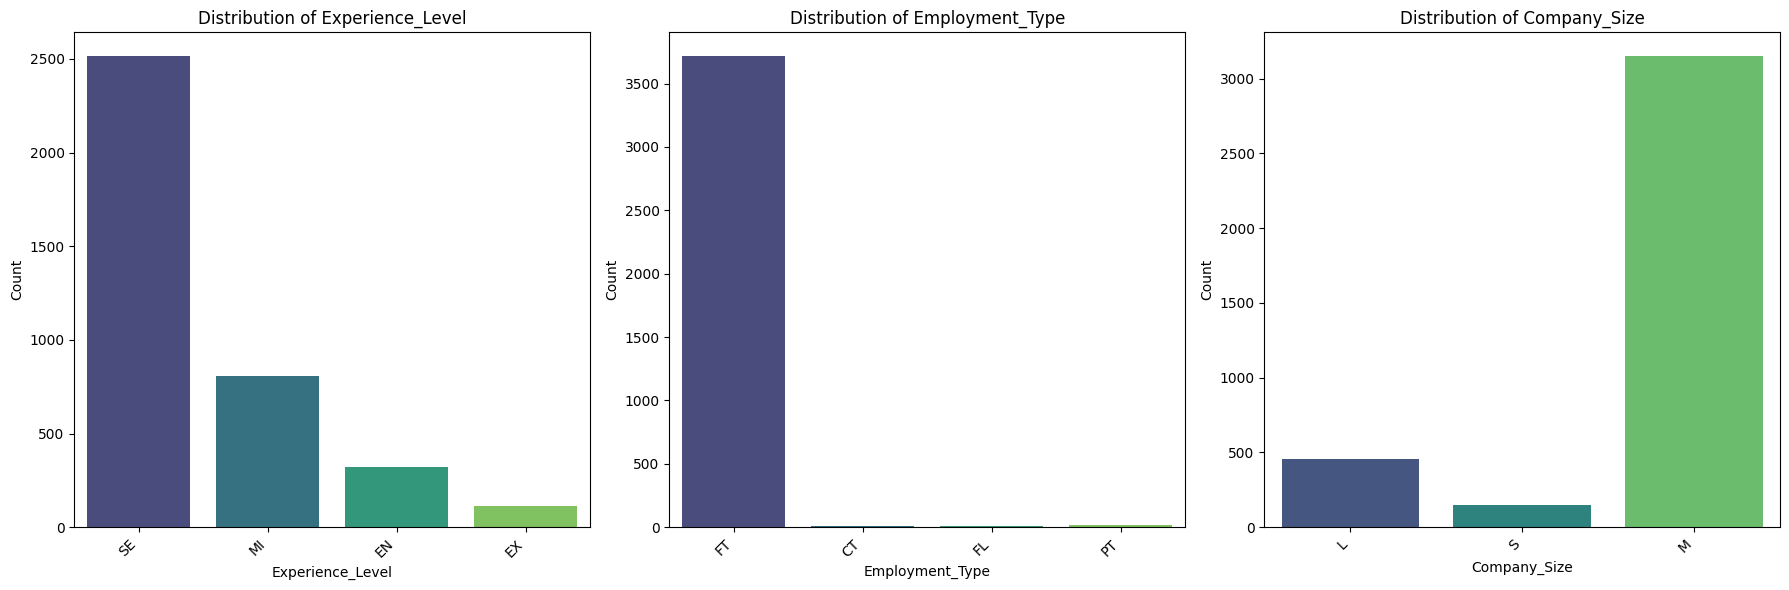

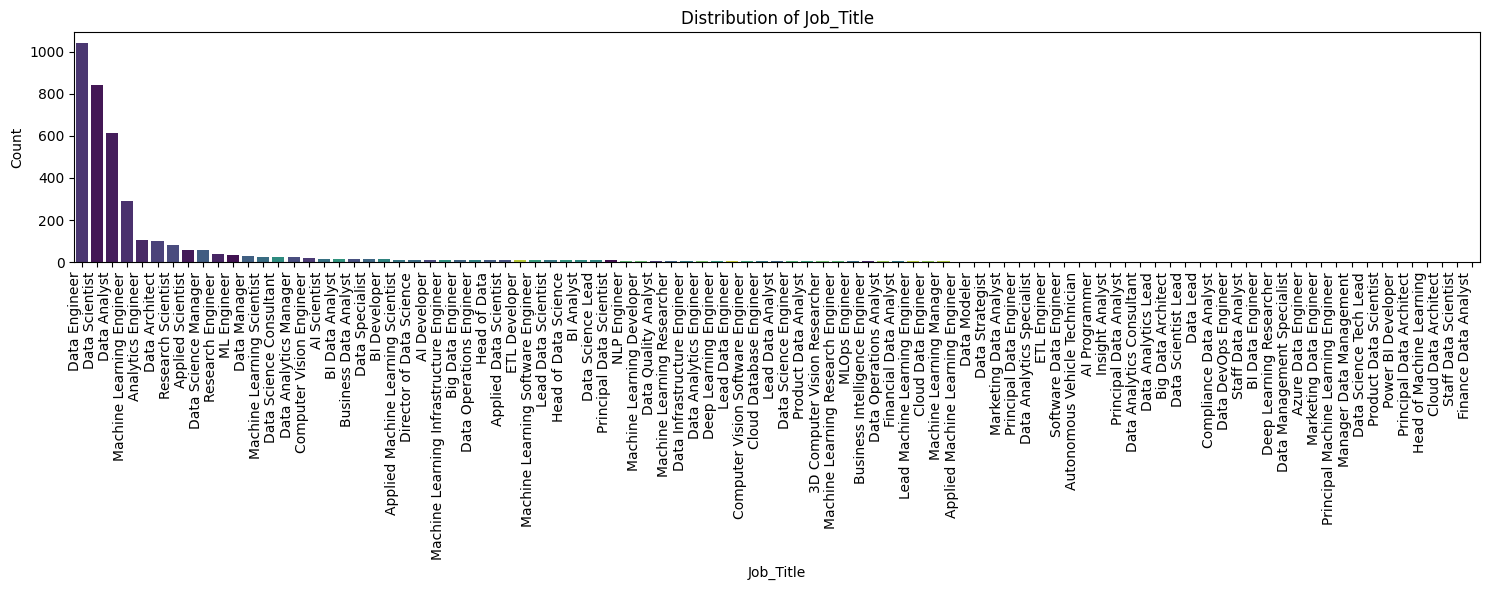

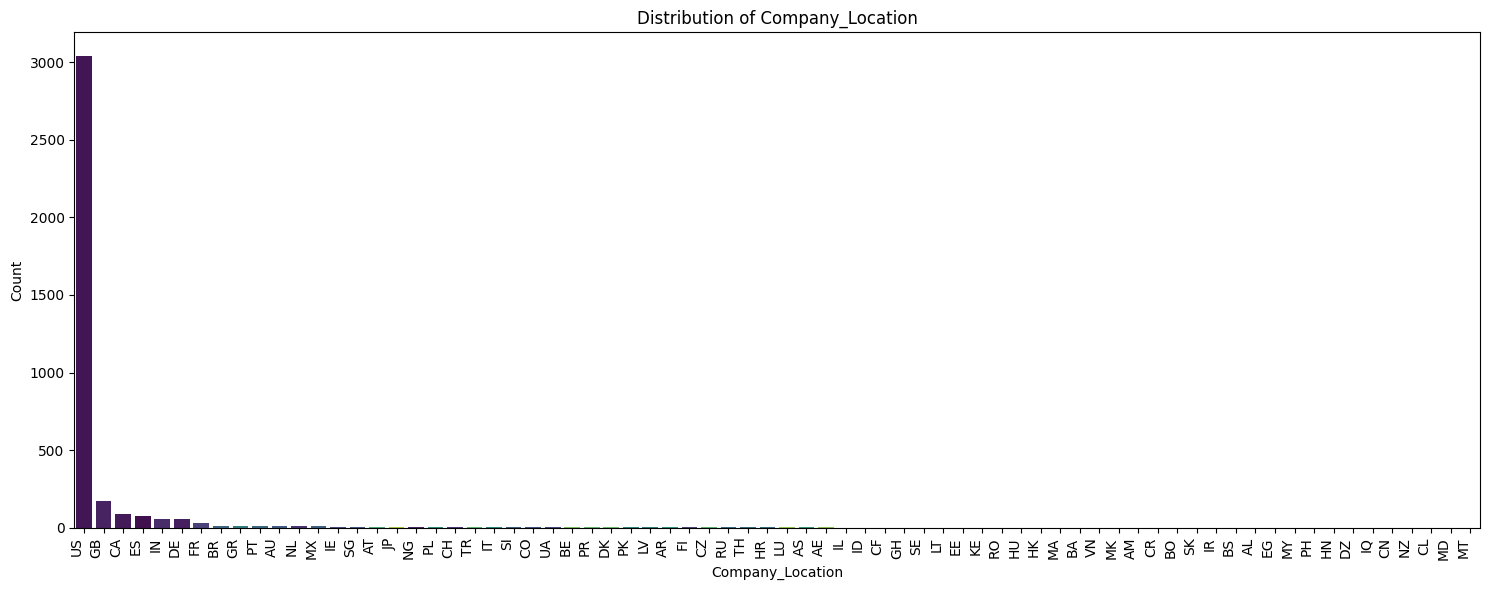

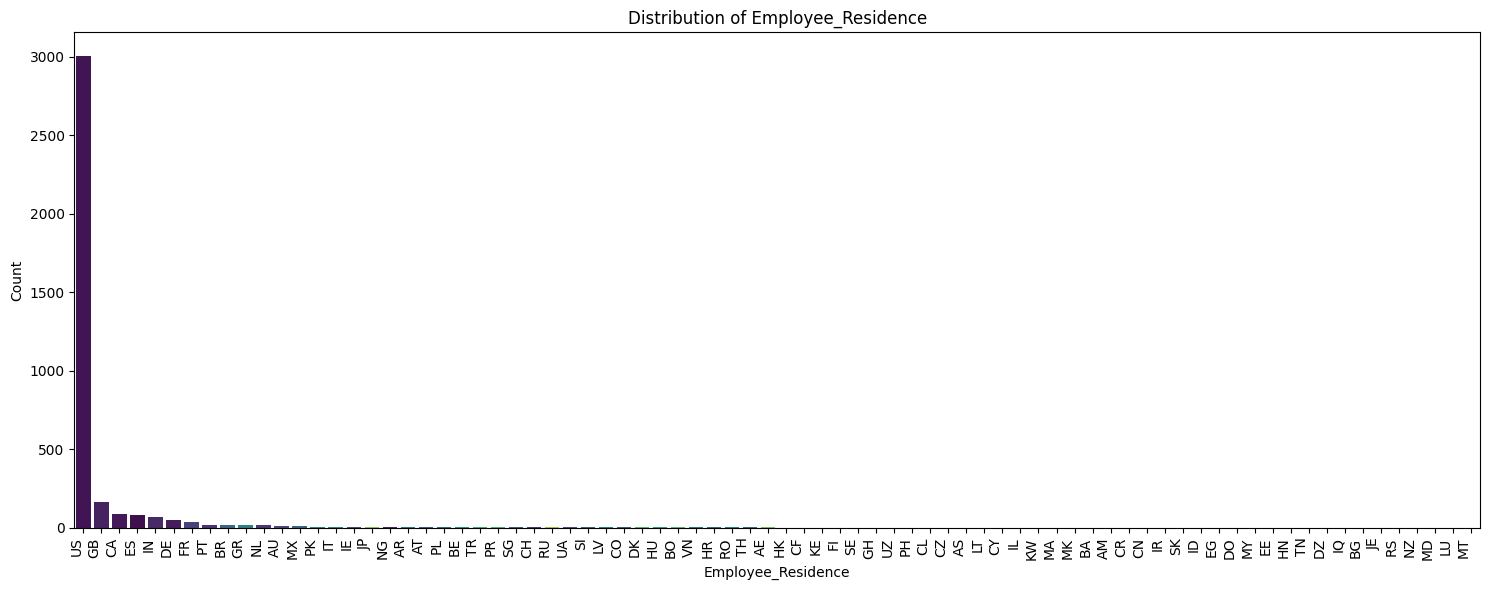

In [87]:
categorical_cols = ['Experience_Level', 'Employment_Type', 'Company_Size']

plt.figure(figsize=(18, 6))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=dataframe, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# For columns with many unique values, create separate plots with adjusted figure sizes
long_categorical_cols = ['Job_Title', 'Company_Location', 'Employee_Residence']

for col in long_categorical_cols:
    plt.figure(figsize=(15, 6))
    sns.countplot(data=dataframe, x=col, hue=col, palette='viridis', legend=False, order=dataframe[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90, ha='right')
    plt.tight_layout()
    plt.show()

## Bivariate Analysis of Salary by Categorical Variables




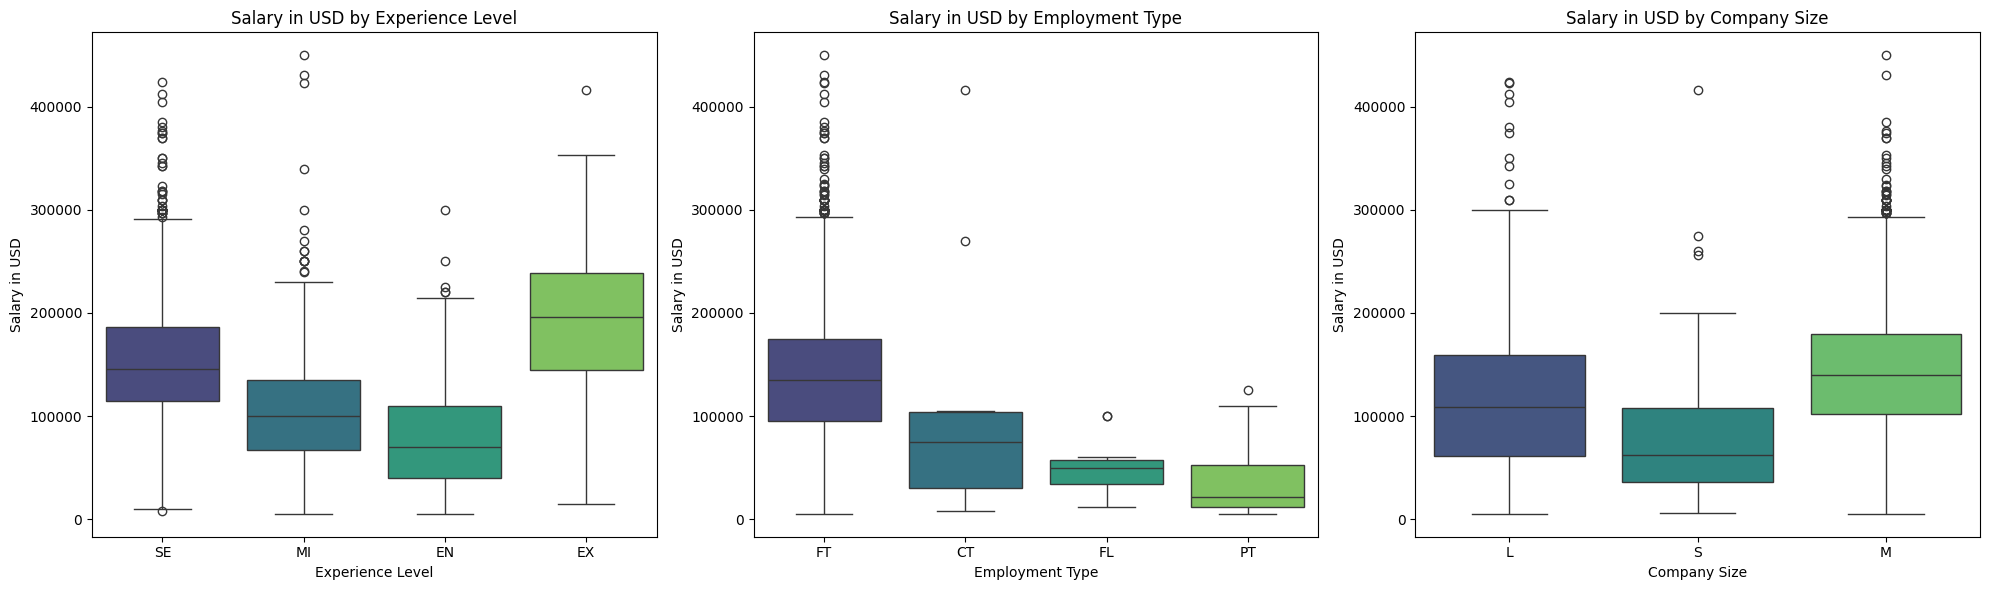

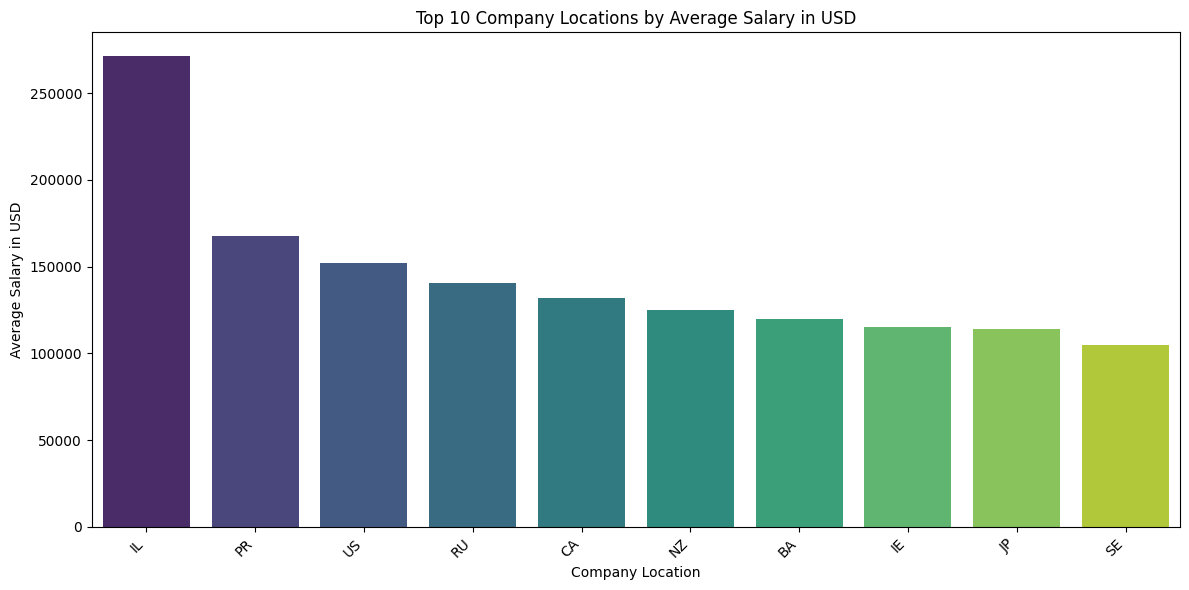

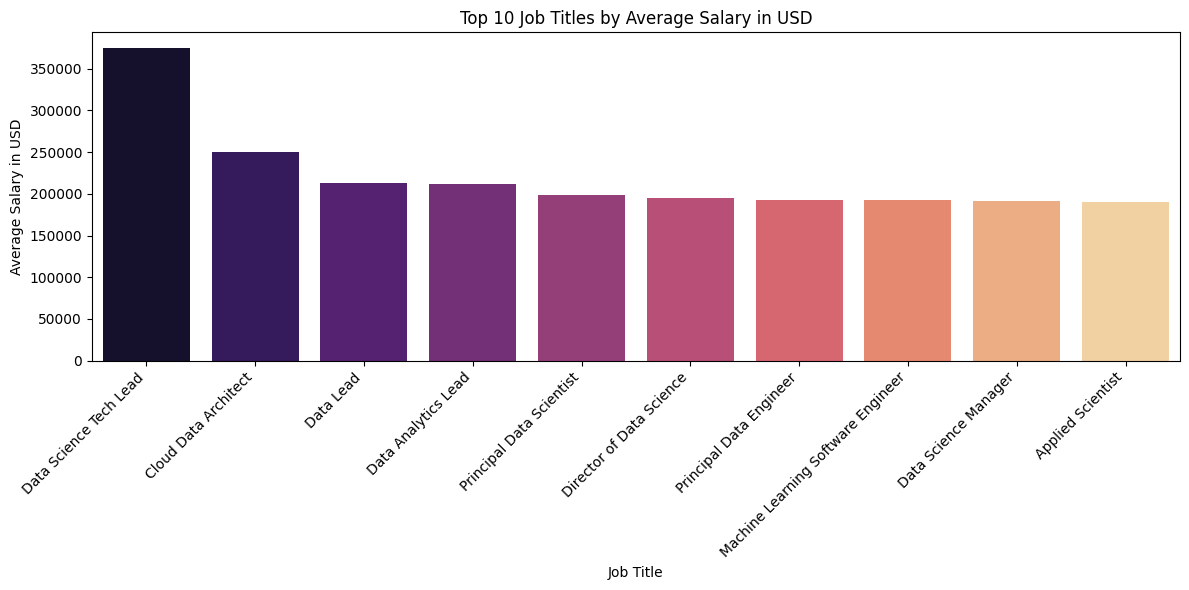

In [83]:
plt.figure(figsize=(20, 6))

# Box plot for Salary_In_USD vs Experience_Level
plt.subplot(1, 3, 1)
sns.boxplot(data=dataframe, x='Experience_Level', y='Salary_In_USD', hue='Experience_Level', palette='viridis', legend=False)
plt.title('Salary in USD by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary in USD')

# Box plot for Salary_In_USD vs Employment_Type
plt.subplot(1, 3, 2)
sns.boxplot(data=dataframe, x='Employment_Type', y='Salary_In_USD', hue='Employment_Type', palette='viridis', legend=False)
plt.title('Salary in USD by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Salary in USD')

# Box plot for Salary_In_USD vs Company_Size
plt.subplot(1, 3, 3)
sns.boxplot(data=dataframe, x='Company_Size', y='Salary_In_USD', hue='Company_Size', palette='viridis', legend=False)
plt.title('Salary in USD by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary in USD')

plt.tight_layout()
plt.show()

# Calculate average Salary_In_USD for top 10 Company_Location
avg_salary_by_company_location = dataframe.groupby('Company_Location')['Salary_In_USD'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_salary_by_company_location.index, y=avg_salary_by_company_location.values, hue=avg_salary_by_company_location.index, palette='viridis', legend=False)
plt.title('Top 10 Company Locations by Average Salary in USD')
plt.xlabel('Company Location')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Calculate average Salary_In_USD for top 10 Job_Title
avg_salary_by_job_title = dataframe.groupby('Job_Title')['Salary_In_USD'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_salary_by_job_title.index, y=avg_salary_by_job_title.values, hue=avg_salary_by_job_title.index, palette='magma', legend=False)
plt.title('Top 10 Job Titles by Average Salary in USD')
plt.xlabel('Job Title')
plt.ylabel('Average Salary in USD')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

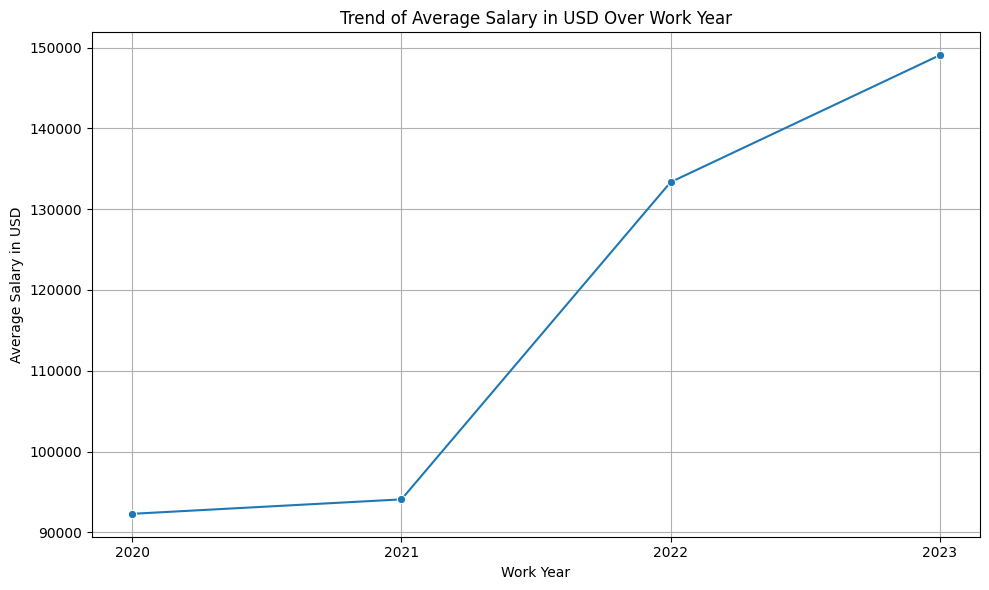

In [84]:
avg_salary_by_work_year = dataframe.groupby('Work_Year')['Salary_In_USD'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=avg_salary_by_work_year, x='Work_Year', y='Salary_In_USD', marker='o')
plt.title('Trend of Average Salary in USD Over Work Year')
plt.xlabel('Work Year')
plt.ylabel('Average Salary in USD')
plt.grid(True)
plt.xticks(avg_salary_by_work_year['Work_Year'])
plt.tight_layout()
plt.show()

##Multivariate analysis

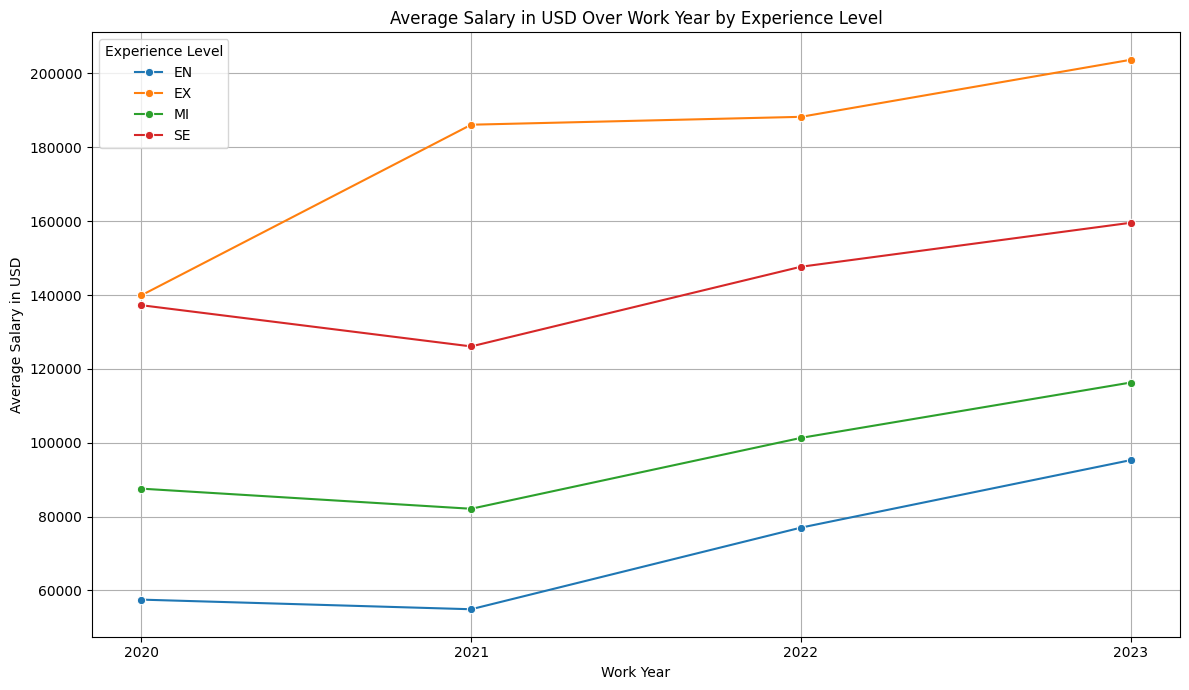

In [85]:
avg_salary_by_year_experience = dataframe.groupby(['Work_Year', 'Experience_Level'])['Salary_In_USD'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.lineplot(data=avg_salary_by_year_experience, x='Work_Year', y='Salary_In_USD', hue='Experience_Level', marker='o', palette='tab10')
plt.title('Average Salary in USD Over Work Year by Experience Level')
plt.xlabel('Work Year')
plt.ylabel('Average Salary in USD')
plt.xticks(avg_salary_by_year_experience['Work_Year'].unique())
plt.grid(True)
plt.legend(title='Experience Level')
plt.tight_layout()
plt.show()

### Correlation Heatmap




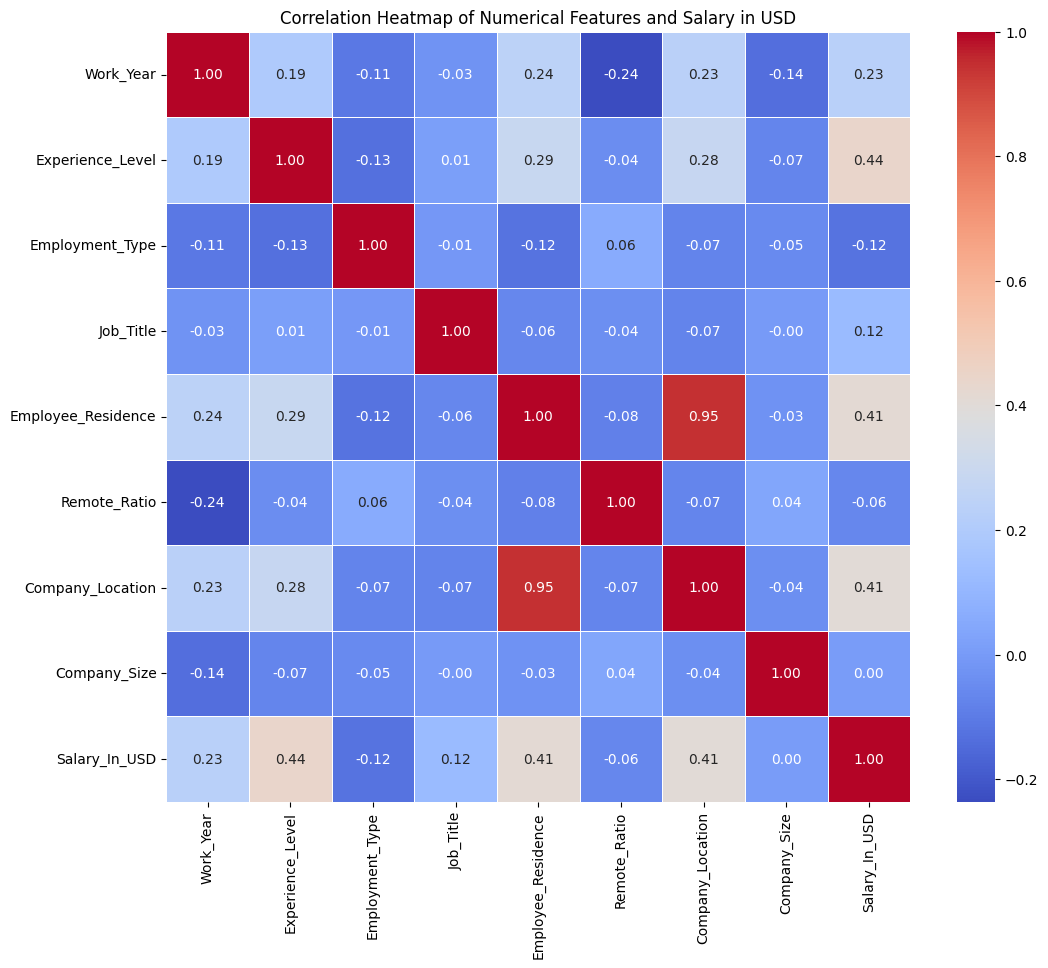

In [49]:
combined_df = X.copy()
combined_df['Salary_In_USD'] = Y

correlation_matrix = combined_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features and Salary in USD')
plt.show()

## 1. Linear Regression


In [91]:


# Initialize and train Linear Regression model
linear_reg = LinearRegression()
linear_reg.fit(X_train, Y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [92]:
# Make predictions on the validation set
y_pred_validate_lr = linear_reg.predict(X_validate)

# Calculate evaluation metrics for validation set
mae_validate_lr = mean_absolute_error(Y_validate, y_pred_validate_lr)
mse_validate_lr = mean_squared_error(Y_validate, y_pred_validate_lr)
rmse_validate_lr = np.sqrt(mse_validate_lr)
r2_validate_lr = r2_score(Y_validate, y_pred_validate_lr)

print("Linear Regression Performance on Validation Set:")
print(f"  MAE: {mae_validate_lr:.2f}")
print(f"  MSE: {mse_validate_lr:.2f}")
print(f"  RMSE: {rmse_validate_lr:.2f}")
print(f"  R-squared: {r2_validate_lr:.2f}")

Linear Regression Performance on Validation Set:
  MAE: 38399.86
  MSE: 2407371367.89
  RMSE: 49064.97
  R-squared: 0.34


In [94]:
# Make predictions on the test set
y_pred_test_lr = linear_reg.predict(X_test)

# Calculate evaluation metrics for test set
mae_test_lr = mean_absolute_error(Y_test, y_pred_test_lr)
mse_test_lr = mean_squared_error(Y_test, y_pred_test_lr)
rmse_test_lr = np.sqrt(mse_test_lr)
r2_test_lr = r2_score(Y_test, y_pred_test_lr)

print("Linear Regression Performance on Test Set:")
print(f"  MAE: {mae_test_lr:.2f}")
print(f"  MSE: {mse_test_lr:.2f}")
print(f"  RMSE: {rmse_test_lr:.2f}")
print(f"  R-squared: {r2_test_lr:.2f}")

Linear Regression Performance on Test Set:
  MAE: 39979.96
  MSE: 2745231098.79
  RMSE: 52394.95
  R-squared: 0.31


## 2. Random Forest Regression


In [95]:



# Initialize and train Random Forest Regressor model
# Using a reasonable number of estimators for a start
rf_reg = RandomForestRegressor(n_estimators=100, random_state=32, n_jobs=-1)
rf_reg.fit(X_train, Y_train)

print("Random Forest Regressor model trained successfully.")

Random Forest Regressor model trained successfully.


In [101]:
y_pred_train_rf = rf_reg.predict(X_train)

mae_train_rf = mean_absolute_error(Y_train, y_pred_train_rf)
mse_train_rf = mean_squared_error(Y_train, y_pred_train_rf)
rmse_train_rf = np.sqrt(mse_train_rf)
r2_train_rf = r2_score(Y_train, y_pred_train_rf)

print("Random Forest Regressor Performance on Training Set:")
print(f"  MAE: {mae_train_rf:.2f}")
print(f"  MSE: {mse_train_rf:.2f}")
print(f"  RMSE: {rmse_train_rf:.2f}")
print(f"  R-squared: {r2_train_rf:.2f}")

Random Forest Regressor Performance on Training Set:
  MAE: 29870.50
  MSE: 1659084698.64
  RMSE: 40731.86
  R-squared: 0.59


In [100]:
# Make predictions on the validation set
y_pred_rf = rf_reg.predict(X_validate)

# Calculate evaluation metrics
mae_rf = mean_absolute_error(Y_validate, y_pred_rf)
mse_rf = mean_squared_error(Y_validate, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(Y_validate, y_pred_rf)

print("Random Forest Regressor Performance on Validation Set:")
print(f"  MAE: {mae_rf:.2f}")
print(f"  MSE: {mse_rf:.2f}")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  R-squared: {r2_rf:.2f}")

Random Forest Regressor Performance on Validation Set:
  MAE: 36076.34
  MSE: 2180705961.13
  RMSE: 46698.03
  R-squared: 0.40


In [99]:
# Make predictions on the test set
y_pred_test_rf = rf_reg.predict(X_test)

# Calculate evaluation metrics
mae_test_rf = mean_absolute_error(Y_test, y_pred_test_rf)
mse_test_rf = mean_squared_error(Y_test, y_pred_test_rf)
rmse_test_rf = np.sqrt(mse_test_rf)
r2_test_rf = r2_score(Y_test, y_pred_test_rf)

print("Random Forest Regressor Performance on Test Set:")
print(f"  MAE: {mae_test_rf:.2f}")
print(f"  MSE: {mse_test_rf:.2f}")
print(f"  RMSE: {rmse_test_rf:.2f}")
print(f"  R-squared: {r2_test_rf:.2f}")

Random Forest Regressor Performance on Test Set:
  MAE: 35819.09
  MSE: 2288538376.57
  RMSE: 47838.67
  R-squared: 0.43


## 3. XGBoost Gradient Boosting



In [36]:


# Initialize and train XGBoost Regressor model
# Using default parameters for a baseline, can be tuned later
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=32, n_jobs=-1)
xgb_reg.fit(X_train, Y_train)

print("XGBoost Regressor model trained successfully.")

XGBoost Regressor model trained successfully.


In [38]:
# Make predictions on the validation set
y_pred_xgb = xgb_reg.predict(X_validate)

# Calculate evaluation metrics
mae_xgb = mean_absolute_error(Y_validate, y_pred_xgb)
mse_xgb = mean_squared_error(Y_validate, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(Y_validate, y_pred_xgb)

print("XGBoost Regressor Performance on Validation Set:")
print(f"  MAE: {mae_xgb:.2f}")
print(f"  MSE: {mse_xgb:.2f}")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  R-squared: {r2_xgb:.2f}")

XGBoost Regressor Performance on Validation Set:
  MAE: 36354.17
  MSE: 2259517184.00
  RMSE: 47534.38
  R-squared: 0.38


## Hyperparameter Tuning for XGBoost (Best Tuned Version)


In [67]:

# 1. Define a parameter distribution for XGBoostRegressor
param_dist_xgb = {
    'n_estimators': randint(50, 200), # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage
    'max_depth': randint(3, 10), # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4), # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.2) # Minimum loss reduction required to make a further partition on a leaf node
}

# 2. Initialize a base XGBRegressor
xgb_base = xgb.XGBRegressor(objective='reg:squarederror', random_state=32, n_jobs=-1)

# 3. Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=50, # Number of parameter settings that are sampled
    cv=5, # Cross-validation folds
    scoring='neg_mean_squared_error', # Metric to evaluate model performance
    random_state=32,
    n_jobs=-1, # Use all available cores
    verbose=1
)

# 4. Fit RandomizedSearchCV to the training data
random_search_xgb.fit(X_train, Y_train)

# 5. Print the best hyperparameters
print("Best hyperparameters found for XGBoost:")
print(random_search_xgb.best_params_)

# 6. Print the best score
print("Best score (Negative MSE) for XGBoost:")
print(random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best hyperparameters found for XGBoost:
{'colsample_bytree': np.float64(0.6758122290116028), 'gamma': np.float64(0.04734241547187117), 'learning_rate': np.float64(0.05231459013307993), 'max_depth': 4, 'n_estimators': 131, 'subsample': np.float64(0.833919202438189)}
Best score (Negative MSE) for XGBoost:
-2422414464.0


In [68]:
# Retrieve the best XGBoost Regressor model
xgb_reg_tuned = random_search_xgb.best_estimator_

# Make predictions on the validation set using the tuned model
y_pred_xgb_tuned_validate = xgb_reg_tuned.predict(X_validate)

# Calculate evaluation metrics
mae_xgb_tuned_validate = mean_absolute_error(Y_validate, y_pred_xgb_tuned_validate)
mse_xgb_tuned_validate = mean_squared_error(Y_validate, y_pred_xgb_tuned_validate)
rmse_xgb_tuned_validate = np.sqrt(mse_xgb_tuned_validate)
r2_xgb_tuned_validate = r2_score(Y_validate, y_pred_xgb_tuned_validate)

print("Tuned XGBoost Regressor Performance on Validation Set:")
print(f"  MAE: {mae_xgb_tuned_validate:.2f}")
print(f"  MSE: {mse_xgb_tuned_validate:.2f}")
print(f"  RMSE: {rmse_xgb_tuned_validate:.2f}")
print(f"  R-squared: {r2_xgb_tuned_validate:.2f}")

Tuned XGBoost Regressor Performance on Validation Set:
  MAE: 35002.01
  MSE: 2016099328.00
  RMSE: 44900.99
  R-squared: 0.45


In [69]:
dataframe['Work_Year'].value_counts()

,count
Work_Year,
2023,1785
2022,1664
2021,230
2020,76


In [70]:
dataframe.isna().sum()

,0
Work_Year,0
Experience_Level,0
Employment_Type,0
Job_Title,0
Salary,0
Salary_Currency,0
Salary_In_USD,0
Employee_Residence,0
Remote_Ratio,0
Company_Location,0


In [71]:
print("Training Set Values: ", X_train.shape, Y_train.shape)
tr_set_size = (2628 / 3755) * 100
print("Training set Size: ",tr_set_size)
print()
print("Validation Set Values: ", X_validate.shape, Y_validate.shape)
val_set_size = (564 / 3755) * 100
print("Validation set Size: ",val_set_size)
print()
print("Test set Values: ", X_test.shape, Y_test.shape)
test_set_size = (564 / 3755) * 100
print("Test set Size: ",test_set_size)


Training Set Values:  (2627, 8) (2627,)
Training set Size:  69.9866844207723

Validation Set Values:  (564, 8) (564,)
Validation set Size:  15.019973368841544

Test set Values:  (564, 8) (564,)
Test set Size:  15.019973368841544


In [72]:
dataframe.loc[dataframe.duplicated()]

,Work_Year,Experience_Level,Employment_Type,Job_Title,Salary,Salary_Currency,Salary_In_USD,Employee_Residence,Remote_Ratio,Company_Location,Company_Size
115,2023,SE,FT,Data Scientist,150000,USD,150000,US,0,US,M
123,2023,SE,FT,Analytics Engineer,289800,USD,289800,US,0,US,M
153,2023,MI,FT,Data Engineer,100000,USD,100000,US,100,US,M
154,2023,MI,FT,Data Engineer,70000,USD,70000,US,100,US,M
160,2023,SE,FT,Data Engineer,115000,USD,115000,US,0,US,M
...,...,...,...,...,...,...,...,...,...,...,...
3439,2022,MI,FT,Data Scientist,78000,USD,78000,US,100,US,M
3440,2022,SE,FT,Data Engineer,135000,USD,135000,US,100,US,M
3441,2022,SE,FT,Data Engineer,115000,USD,115000,US,100,US,M
3586,2021,MI,FT,Data Engineer,200000,USD,200000,US,100,US,L


In [73]:
dataframe.dtypes

,0
Work_Year,int64
Experience_Level,object
Employment_Type,object
Job_Title,object
Salary,int64
Salary_Currency,object
Salary_In_USD,int64
Employee_Residence,object
Remote_Ratio,int64
Company_Location,object


## XGBoost tuned test set



In [41]:
# Make predictions on the test set using the tuned XGBoost model
y_pred_xgb_tuned_test = xgb_reg_tuned.predict(X_test)

# Calculate evaluation metrics for test set
mae_xgb_tuned_test = mean_absolute_error(Y_test, y_pred_xgb_tuned_test)
mse_xgb_tuned_test = mean_squared_error(Y_test, y_pred_xgb_tuned_test)
rmse_xgb_tuned_test = np.sqrt(mse_xgb_tuned_test)
r2_xgb_tuned_test = r2_score(Y_test, y_pred_xgb_tuned_test)

print("Tuned XGBoost Regressor Performance on Test Set:")
print(f"  MAE: {mae_xgb_tuned_test:.2f}")
print(f"  MSE: {mse_xgb_tuned_test:.2f}")
print(f"  RMSE: {rmse_xgb_tuned_test:.2f}")
print(f"  R-squared: {r2_xgb_tuned_test:.2f}")

Tuned XGBoost Regressor Performance on Test Set:
  MAE: 35941.42
  MSE: 2245615360.00
  RMSE: 47387.92
  R-squared: 0.44


##Visualize Tuned XGBoost Training Predictions


In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x=Y_train, y=y_pred_train_xgb_tuned, alpha=0.6)

# Add a line for perfect predictions
min_val = min(Y_train.min(), y_pred_train_xgb_tuned.min())
max_val = max(Y_train.max(), y_pred_train_xgb_tuned.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Tuned XGBoost: Actual vs. Predicted Salaries on Training Data')
plt.xlabel('Actual Salary in USD (Training)')
plt.ylabel('Predicted Salary in USD (Training)')
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensure both axes have the same scaling
plt.show()

## Visualize Tuned XGBoost Test Predictions

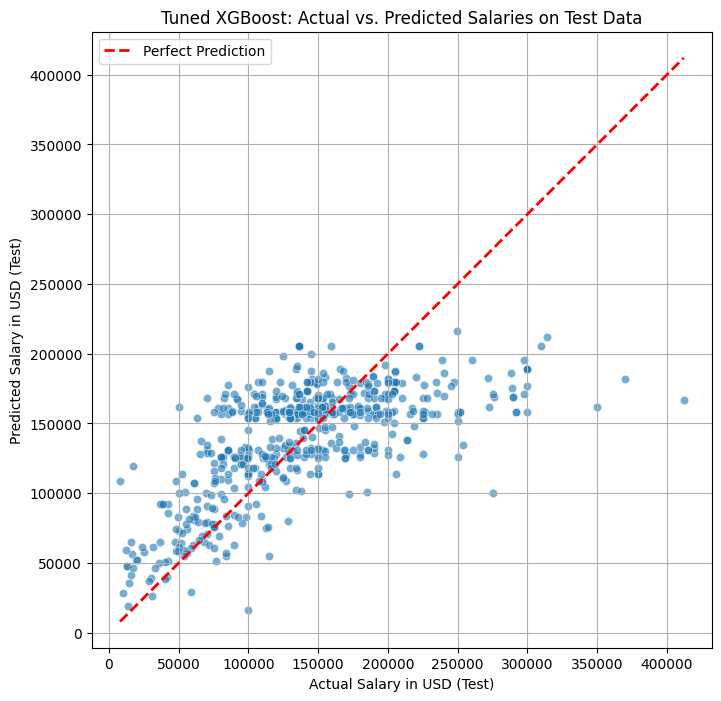

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 8))
sns.scatterplot(x=Y_test, y=y_pred_xgb_tuned_test, alpha=0.6)

# Add a line for perfect predictions
min_val = min(Y_test.min(), y_pred_xgb_tuned_test.min())
max_val = max(Y_test.max(), y_pred_xgb_tuned_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Tuned XGBoost: Actual vs. Predicted Salaries on Test Data')
plt.xlabel('Actual Salary in USD (Test)')
plt.ylabel('Predicted Salary in USD (Test)')
plt.grid(True)
plt.legend()
plt.axis('equal') # Ensure both axes have the same scaling
plt.show()